In [1]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    #total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    #use geqdsk pressure for now
    total_pressure = gfile['PRES']
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

In [2]:
from netCDF4 import Dataset
from sys import argv
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import xarray as xr
from omfit_classes import omfit_eqdsk
import math

In [3]:


# Find the fastran.nc files ================
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]
#sims.remove('simulation_2252149_0008')

# Define arrays ===========================
rho_array = []
irf_array = []
prf_array = []
pfus_array = [] 
jrf_array_array = [] #array_arrays are for profiles that I want colored with a colorbar'
jtot_array_array = []
psol_array = []
te_array_array = []
ti_array_array = []
prf_array_array = []
ne_array_array = []
ni_array_array = []
nz1frac_array = []
nebar_array = []
total_ptcls_array = []
pe_array_array = []
betan_array = []
pfus_array_array = []
p_array_array = []
sion_array_array = []
param_0_array = []
param_1_array = []

geqdsk_array = []

count = []
for sim in sims:
    try:
        work_dir = SCAN_dir+'/'+sim+'/work'
        fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
        ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
        gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'
        geqdsk = omfit_eqdsk.OMFITeqdsk(gfile)
        geqdsk_array.append(geqdsk)

        rootgrp = Dataset(ffile)

        # # GET PARAMETERS FROM SCAN FILE
        # param_file = SCAN_dir+'/'+sim+'/'+'parameters.conf'
        # params_table = np.genfromtxt(param_file,dtype=None,usecols=[1,2],encoding=None)
    
        # param_0_name,param_0_val = params_table[-1]
        # param_1_name,param_1_val = params_table[-2]

        # param_0_array.append(param_0_val)
        # param_1_array.append(param_1_val)


        #Define variables from netcdf file -------------------------------
        rho = rootgrp['rho'][:]
        rho_array.append(rho)

        
        # densities
        ne = rootgrp['ne'][-1,:]
        nebar = rootgrp['nebar'][-1]
        ni = rootgrp['ni'][-1,:]
        nz0 = rootgrp['nz0'][-1,:]
        nz1 = rootgrp['nz1'][-1,:]
        nhe = rootgrp['nhe'][-1,:] # I set this to -2 before? why?
        
        nebar_array.append(nebar)
        nz1frac_array.append(nz1[0]/ne[0])
        ne_array_array.append(ne)
        ni_array_array.append(ni + nz0 + nz1 + nhe)

        sion = rootgrp['sion'][-1,:]
        sn_tot = vol_integral(geqdsk, sion, rho_prof = rho)
        total_ptcls_array.append(sn_tot)

        # temperatures
        te = rootgrp['te'][-1,:]
        teavg = rootgrp['tea'][-1]
        ti = rootgrp['ti'][-1,:]
        tiavg = rootgrp['tia'][-1]

        te_array_array.append(te)
        ti_array_array.append(ti)
        pe_array_array.append(ne*te)
    
        ipol = rootgrp['ipol'][-1,:]
        ip = rootgrp['ip'][-1]
    
        prfe = rootgrp['pe_rf'][-1,:]
        prfe_int = rootgrp['prfe'][-1]
        prfi = rootgrp['pi_rf'][-1,:]
        prfi_int = rootgrp['prfi'][-1]
        prf_array.append(prfe_int+prfi_int)
        prf_array_array.append(prfe+prfi)        
    
        pfuse = rootgrp['pe_fus'][-1,:]
        pfuse_int = rootgrp['pfuse'][-1]
        pfusi = rootgrp['pi_fus'][-1,:]
        pfusi_int = rootgrp['pfusi'][-1]

        prad_int = rootgrp['prad'][-1]
    
        q = rootgrp['q'][-1,:]
    
        jbs = rootgrp['j_bs'][-1,:]
        ibs = rootgrp['ibs'][-1]
        joh = rootgrp['j_oh'][-1,:]
        jrf = rootgrp['j_rf'][-1,:]
        irf = rootgrp['irf'][-1]
        jtot = rootgrp['j_tot'][-1,:]
    
        fluxe = rootgrp['fluxe'][-1,:]
        fluxe_exp = rootgrp['fluxe_exp'][-1,:]
        fluxi = rootgrp['fluxi'][-1,:]
        fluxi_exp = rootgrp['fluxi_exp'][-1,:]

        betan = rootgrp['betan'][-1]

        betan_array.append(betan)
        irf_array.append(irf)
        pfus_array.append(5*(pfuse_int+pfusi_int))
        psol_array.append((pfuse_int+pfusi_int)+prfe_int+prfi_int+prad_int) # is this right?

        pfus_array_array.append((5*(pfuse+pfusi)))
        p_array_array.append(ne*te + (ni+nz0+nz1+nhe)*ti)
        jrf_array_array.append(jrf)
        jtot_array_array.append(jtot)

    except IndexError:
        print('{:s} netcdf empty'.format(sim))
        if count:
            count.pop() #don't count most recent count append if IndexError
        if rho_array:
            rho_array.pop()




9 9 9


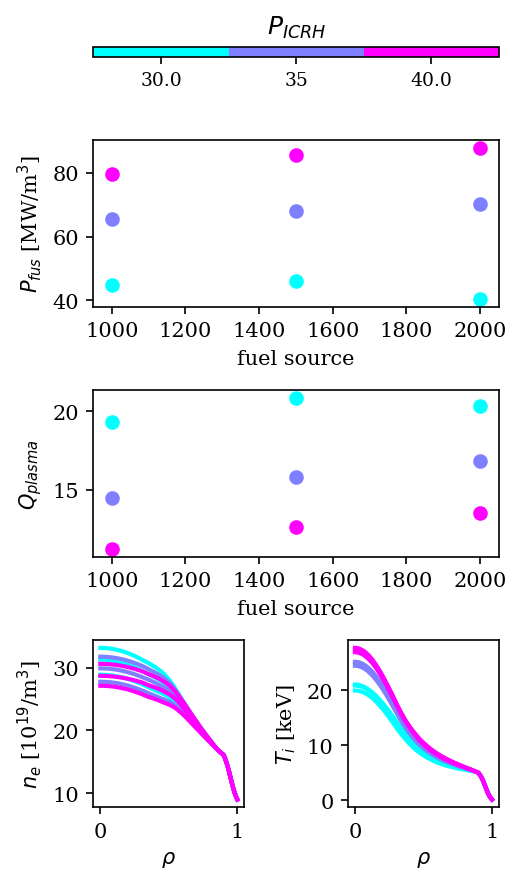

[40.01400882105115, 30.00591921595877, 40.011218954915236, 20.002046811435008, 20.00253454680776, 20.007106048789243, 40.010749501093166, 30.010252333946887, 30.007074016833315]


In [4]:
with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 10,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 2.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    # DEFINE FIGURE ===========================
    fig = plt.figure('fig_offset', figsize=(3.58,6),dpi = 150)
    gs = mpl.gridspec.GridSpec(4,2, figure=fig, height_ratios = [0.06,1,1,1])
    axs = {}
    axs[1] = fig.add_subplot(gs[1,:])
    axs[2] = fig.add_subplot(gs[2,:])
    axs[3] = fig.add_subplot(gs[3,0])
    axs[4] = fig.add_subplot(gs[0,:])
    axs[5] = fig.add_subplot(gs[3,1])
    
    ax1 = axs[1]
    ax2 = axs[3]
    ax3 = axs[5]
    ax1cb = axs[4]
    ax4 = axs[2]
    

    cvar = prf_array
    yvar = pfus_array_array
    xvar = total_ptcls_array
    print(len(cvar),len(yvar),len(xvar))

    # set colors for colorbar
    cmap = cm.get_cmap('cool')
    cmin = min(cvar)
    cmax = max(cvar)
    cs = (cvar-cmin)/(cmax-cmin)
    c = cmap(cs)
    order = np.argsort(cs)
    
    # make colorbar
    Ncb = 3
    mintick = 30; maxtick = 40
    ticklabels = np.linspace(mintick,maxtick,Ncb)
    ticks = (ticklabels-cmin)/(cmax-cmin)
    tick_diff = (ticks[1]-ticks[0])/2
    bounds = [ticks[0]-tick_diff] + [ticks[i]+tick_diff for i in range(len(ticks)-1)] + [ticks[-1]+tick_diff] #make the ticks be in the center of the color boundaries
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    cb1 = mpl.colorbar.ColorbarBase(ax1cb, orientation='horizontal', cmap=cmap, ticks = ticks, norm = norm, extend=None)
    ticklabels_s = ['{:1.0f}'.format(x) for x in ticklabels]
    ticklabels_s[0] = f'{ticklabels[0]}'
    ticklabels_s[-1] = f'{ticklabels[-1]}'
    cb1.set_ticklabels(ticklabels_s,fontsize=9)
    ax1cb.set_title('$P_{ICRH}$')

    for i in order:
        ax2.plot(rho_array[i],ne_array_array[i],color=c[i])    
        ax3.plot(rho_array[i],ti_array_array[i],color=c[i])
        ax1.scatter(xvar[i],psol_array[i],color=c[i])
        ax4.scatter(xvar[i],pfus_array[i]/prf_array[i],color=c[i])

    #ax1.set_xticks(ticklabels)
    #ax4.set_xticks(ticklabels)
    ax1.set_xlabel('fuel source')
    ax4.set_xlabel('fuel source')
    ax2.set_xlabel('$\\rho$')
    ax3.set_xlabel('$\\rho$')
    
    #for letter,ax in zip(['(a)','(b)','(c)'],[ax1,ax2,ax3]):
    #    ax.text(0.9,0.85,'{:s}'.format(letter), transform=ax.transAxes)

    ax2.set_ylabel('$n_e$ [10$^{19}$/m$^3$]')
    ax3.set_ylabel('$T_i$ [keV]')
    ax1.set_ylabel('$P_{fus}$ [MW/m$^3$]')
    ax4.set_ylabel('$Q_{plasma}$')
    # Make plots share x axis
    #plt.setp(ax1.get_xticklabels(), visible=False)

    # Make a solid/dashed legend
    #ax1.plot(0,0,color = 'k',label='density [10$^{19}$/m$^3$]')
    #ax1.plot(0,0,color = 'k',linestyle='dashed',linewidth=1,label='source [10$^{19}$/(m$^3\\cdot$ s)]')
    #ax1.legend(fontsize=8,frameon=False,loc="upper left")

    #plt.savefig('paux_scan.pdf',format='pdf',dpi = 300)
    plt.show()
print(prf_array)

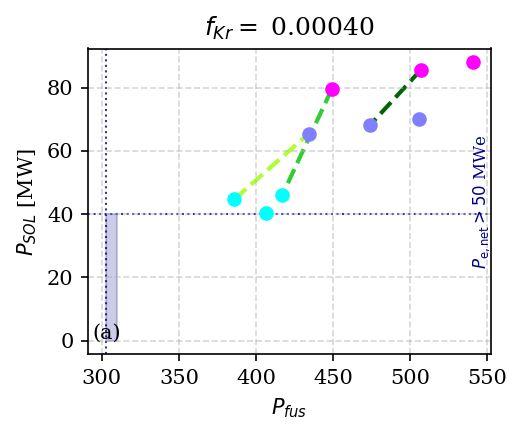

In [6]:
with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 10,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 2.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    # DEFINE FIGURE ===========================
    fig = plt.figure('fig_offset', figsize=(3.58,3),dpi = 150)
    gs = mpl.gridspec.GridSpec(1,1, figure=fig)
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])

    ax1 = axs[1]

    # Plot lines for each total_ptcls
    sntot_order = np.argsort(total_ptcls_array)
    linecolor = ['greenyellow','limegreen','darkgreen']
    for j,k in zip([0,2,4],[2,4,6]):
        temp_Qp = [pfus_array[i] for i in sntot_order[j:k]]
        temp_psol = [psol_array[i] for i in sntot_order[j:k]]
        ax1.plot(temp_Qp,temp_psol,linestyle='dashed',color = linecolor[int(j/2)],zorder=0)


    ### DIFFERENT FOR TOP PLOT
    cvar = np.array([20,30,40])

    # set colors for colorbar
    cmap = cm.get_cmap('cool')
    cmin = min(cvar)
    cmax = max(cvar)
    cs = (cvar-cmin)/(cmax-cmin)
    c = cmap(cs)
    order = np.argsort(prf_array)

    # Plot points
    for i in order:
        if (prf_array[i]-20) < 1:
            color = c[0]
        elif (prf_array[i]-30) < 1:
            color = c[1]
        elif (prf_array[i]-40) < 1:
            color = c[2]
                
        ax1.scatter(pfus_array[i],psol_array[i],color=color,label='%.0f MW'%(prf_array[i]))

    ax1.set_xlabel('$P_{fus}$')
    
    ax1.set_ylabel('$P_{SOL}$ [MW]')
    #ax1.legend()

    # # Make custom legend
    # height = 0.9
    # ax1.fill_betweenx(y=[height-3*0.05,height+0.05], x1 = 0.05, x2 = 0.95, color = 'white', edgecolor = 'gray',alpha = 1.0,joinstyle='bevel',transform=ax1.transAxes)
    # x1 = 0.1; x2 = 0.4; x3 = 0.7
    # ax1.scatter([x1],[height],color = c[0],transform=ax1.transAxes)
    # ax1.scatter([x2],[height],color = c[1],transform=ax1.transAxes)
    # ax1.scatter([x3],[height],color = c[2],transform=ax1.transAxes)
    # ax1.text(x1+0.03,height-0.02,'20 MW',transform=ax1.transAxes,fontsize = 8)
    # ax1.text(x2+0.03,height-0.02,'30 MW',transform=ax1.transAxes,fontsize = 8)
    # ax1.text(x3+0.03,height-0.02,'40 MW',transform=ax1.transAxes,fontsize = 8)

    # dx = 0.02; dh = 0.1
    # ax1.plot([x1-dx,x1+dx],[height-dh,height-dh],color = linecolor[0],transform=ax1.transAxes)
    # ax1.plot([x2-dx,x2+dx],[height-dh,height-dh],color = linecolor[1],transform=ax1.transAxes)
    # ax1.plot([x3-dx,x3+dx],[height-dh,height-dh],color = linecolor[2],transform=ax1.transAxes)
    # ax1.text(x1+0.04,height-dh-0.02,'source 1',transform=ax1.transAxes,fontsize = 8)
    # ax1.text(x2+0.04,height-dh-0.02,'source 2',transform=ax1.transAxes,fontsize = 8)
    # ax1.text(x3+0.04,height-dh-0.02,'source 3',transform=ax1.transAxes,fontsize = 8)

    goodbox_color = 'darkblue'
    #ax1.set_xlim(190,310)
    #ax1.set_ylim(0,90)
    ax1.axvline(303,color=goodbox_color,linewidth=1,linestyle='dotted',alpha=0.8,zorder=0)
    ax1.axhline(40,color=goodbox_color,linewidth=1,linestyle='dotted',alpha=0.8,zorder=0)
    ax1.fill_betweenx(y=[0, 40], x1=303, x2=310, color=goodbox_color, alpha=0.2,zorder=0)
    ax1.text(0.95,0.3,'$P_{\\mathrm{e,net}}> 50$ MWe',rotation='vertical',transform = ax1.transAxes,color = goodbox_color,fontsize=8)
    
    ax1.set_title('$f_{Kr} =$ %0.5f'%(nz1[0]/ne[0]))
    ax1.text(0.01,0.05,'(a)',transform = ax1.transAxes)
    plt.savefig('paux_scan_0005_pfus.pdf',format='pdf',dpi = 300)
    
    ax1.set_axisbelow(True)
    ax1.grid(linestyle='dashed',zorder=0,alpha =0.5)
    plt.show()


In [13]:
print([total_ptcls_array[i] for i in sntot_order])

[500.2330617976604, 500.2360661904297, 700.315276197017, 700.3225910729537, 900.3768138472738, 900.3806522420656]


In [7]:
dataset = xr.open_dataset(ffile)

In [8]:
print(dataset['ne'])

<xarray.DataArray 'ne' (time: 3, rho: 101)>
array([[20.763221, 20.763221, 20.762037, ...,  9.819731,  9.34606 ,  8.972966],
       [20.750925, 20.750531, 20.749346, ...,  9.819731,  9.34606 ,  8.972966],
       [20.750925, 20.750531, 20.749346, ...,  9.819731,  9.34606 ,  8.972966]])
Coordinates:
  * time     (time) float64 9.969e+36 9.969e+36 9.969e+36
  * rho      (rho) float64 0.0 0.01 0.02 0.03 0.04 ... 0.96 0.97 0.98 0.99 1.0


In [9]:
cmin = min(cvar)
cmax = max(cvar)
cs = (cvar-cmin)/(cmax-cmin)
c = cmap(cs)
order = np.argsort(cs)

# make colorbar
Ncb = 4
mintick = 150; maxtick = 300
ticklabels = np.linspace(mintick,maxtick,Ncb)
ticks = [(i-cmin)/(cmax-cmin) for i in ticklabels]

In [10]:
print(ticks)

[6.5, 9.0, 11.5, 14.0]


In [11]:
(8.5-6.5)/6.5

0.3076923076923077